### **Geo-Targeted Sales Optimizer**

For this project, I implemented a lightweight, high-performance **Prescriptive Analytics Pipeline** using **Python** and **DuckDB**. The engine ingests disparate datasets (macroeconomics, regional demographics, and historical sales velocity), processes them via a high-performance database layer, runs a deterministic multi-vector scoring algorithm, applies hard corporate constraints (such as, Customer Acquisition Cost limits), outputs a weighted Expansion Index ($EI$) to identify optimal regional targets, and auto-generates localized executive insights.



### Initializing a local Database & ingesting Datasets into native relational tables

In [18]:
import os
import duckdb

def initialize_database(db_path='data/sales_optimizer.db', data_dir='data'):
    print(f"Connecting to database at: {db_path}")
    con = duckdb.connect(db_path)
    
    # Defining file target paths
    macro_csv = os.path.join(data_dir, 'raw_macro_trends.csv')
    sales_csv = os.path.join(data_dir, 'raw_sales_velocity.csv')
    
    # Ingesting Raw Datasets into Staging Tables
    print("Ingesting staging datasets into relational tables...")
    con.execute(f"""
        CREATE OR REPLACE TABLE staging_macro AS 
        SELECT * FROM read_csv_auto('{macro_csv}');
    """)
    
    con.execute(f"""
        CREATE OR REPLACE TABLE staging_sales AS 
        SELECT * FROM read_csv_auto('{sales_csv}');
    """)
    
    # Building Analytical Normalization View
    # Normalization formula: (x - min) / (max - min)
    print("Creating normalized analytical view: v_normalized_market_metrics...")
    con.execute("""
        CREATE OR REPLACE VIEW v_normalized_market_metrics AS 
        WITH bounds AS (
            SELECT 
                MIN(m.gdp_growth_rate) AS min_gdp, MAX(m.gdp_growth_rate) AS max_gdp,
                MIN(m.inflation_rate) AS min_inf, MAX(m.inflation_rate) AS max_inf,
                MIN(s.historical_sales_usd) AS min_sales, MAX(s.historical_sales_usd) AS max_sales,
                MIN(s.competitor_density_score) AS min_comp, MAX(s.competitor_density_score) AS max_comp
            FROM staging_macro m
            JOIN staging_sales s ON m.region_id = s.region_id
        )
        SELECT 
            m.region_id,
            m.country,
            m.city,
            s.historical_sales_usd,
            
            -- Min-Max Normalization Calculations
            CASE 
                WHEN (b.max_sales - b.min_sales) = 0 THEN 0.0
                ELSE ROUND((s.historical_sales_usd - b.min_sales) / (b.max_sales - b.min_sales), 4)
            END AS norm_sales,
            
            CASE 
                WHEN (b.max_gdp - b.min_gdp) = 0 THEN 0.0
                ELSE ROUND((m.gdp_growth_rate - b.min_gdp) / (b.max_gdp - b.min_gdp), 4)
            END AS norm_gdp,
            
            CASE 
                WHEN (b.max_inf - b.min_inf) = 0 THEN 0.0
                ELSE ROUND((m.inflation_rate - b.min_inf) / (b.max_inf - b.min_inf), 4)
            END AS norm_inflation,
            
            CASE 
                WHEN (b.max_comp - b.min_comp) = 0 THEN 0.0
                ELSE ROUND((s.competitor_density_score - b.min_comp) / (b.max_comp - b.min_comp), 4)
            END AS norm_competition,
            
            s.customer_acquisition_cost_usd
            
        FROM staging_macro m
        JOIN staging_sales s ON m.region_id = s.region_id
        CROSS JOIN bounds b;
    """)
    
    print(" Database and Analytical Views initialized successfully.")
    con.close()

if __name__ == "__main__":
    initialize_database()

Connecting to database at: data/sales_optimizer.db
Ingesting staging datasets into relational tables...
Creating normalized analytical view: v_normalized_market_metrics...
 Database and Analytical Views initialized successfully.


Within the defined func initialize_database() above, we built an inline analytical view that handles the Min-Max Normalization calculations for the succeeding scoring components. This scales variables with different units (like $10M in sales vs. a 4.2% inflation rate) into a uniform 0.0 to 1.0 scale.
######

### The Automation & Optimization Layer

The Expansion Index ($EI$) Formula:The scoring algorithm calculates the final index by rewarding economic growth and commercial traction while heavily penalizing inflation and market saturation:$$EI = w_1(\text{GDP Growth}_{norm} - \text{Inflation}_{norm}) + w_2(\text{Disposable Income}_{norm}) + w_3(\text{Sales Velocity}_{norm} - \text{Competitor Density}_{norm})$$The engine is designed to explicitly flag "High-Inflation Traps" (high historical sales but eroding economies) and discover "Hidden Gems" (low competition, stable economic growth).

Now, we turn the data into automated decision by:
1. Quering the nrmalized feature data fromthe database.
2. Executing the composite scoring algorithm.
3. isolating optimal targets based on strict corporate budget constraints.
4. parsing the top 5 cities. and ultimately,
5. Generating a clean executive report ready for a C-suite presentation.

In [52]:
import pandas as pd

def run_market_optimization(db_path='data/sales_optimizer.db'):
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database missing at {db_path}. Please execute db_manager.py first.")
        
    con = duckdb.connect(db_path)
    
    #  Extracting Normalized Feature Data from DuckDB
    query = "SELECT * FROM v_normalized_market_metrics;"
    df = con.query(query).df()
    con.close()
    
    #  Vectorized Math Engine: Composite Market Scoring
    #  Inverting inflation and competition scores because lower values are favorable
    df['market_score'] = (
        (0.35 * df['norm_sales']) +
        (0.35 * df['norm_gdp']) +
        (0.15 * (1.0 - df['norm_inflation'])) +
        (0.15 * (1.0 - df['norm_competition']))
    )
    df['market_score'] = df['market_score'].round(4)
    
    #  Applying Executive Strategic Hard Constraints
    # Rule 1: CAC must be under $300 USD
    # Rule 2: Inflation must not exceed 10% (0.10)
    df['passed_constraints'] = (df['customer_acquisition_cost_usd'] <= 300.0) & (df['norm_inflation'] < 0.50) # relative scale: upper 50% market rejection
    
    df = df.sort_values(by='market_score', ascending=False).reset_index(drop=True)
    return df

###
###
### Reporting

In [74]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def generate_executive_report(df, output_path='reports/executive_summary.md'):
    """Compiles analytical outcomes into a clean, scannable Markdown briefing."""
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # Isolating targets
    viable_markets = df[df['passed_constraints']].head(5)
    traps_identified = df[df['city'].str.contains('Trap', case=False)]
    gems_identified = df[df['city'].str.contains('Gem', case=False)]
    
    markdown_content = fr"""# Executive Briefing: Global Market Expansion Optimization
**Data Pipeline Status:** Production Ready  
**Analysis Framework:** Composite Risk/Velocity Optimization (Weights: 35% Sales, 35% GDP, 15% Inf, 15% Comp)

---

## Strategic Recommendation: Top 5 Expansion Targets
These territories cleared all strategic guardrails (CAC $\le$ $300, Inflation Risk < High) and offer the peak efficiency returns.

| Rank | City | Country | Historical Sales | Market Score | CAC |
| :--- | :--- | :--- | :--- | :--- | :--- |
{chr(10).join([f"| {i+1} | {row['city']} | {row['country']} | ${row['historical_sales_usd']:,.2f} | **{row['market_score']:.4f}** | ${row['customer_acquisition_cost_usd']:.2f} |" for i, row in viable_markets.iterrows()])}

---

## Pipeline Stress-Test: Archetype Validations

### 1. The High-Inflation Traps (High Volume / Exploding Macro Risk)
*Goal: The framework must flag and bypass these high-performing vanity revenue markets.*

| City | Historical Sales | Norm Inflation | Passed Constraints? | Market Score |
| :--- | :--- | :--- | :--- | :--- |
{chr(10).join([f"| {row['city']} | ${row['historical_sales_usd']:,.2f} | {row['norm_inflation']:.2f} | {row['passed_constraints']} | {row['market_score']:.4f} |" for _, row in traps_identified.iterrows()])}

### 2. The Hidden Gems (Moderate Volume / Low Competition / Stable Macro)
*Goal: Identify under-the-radar, high-efficiency expansion vectors.*

| City | Historical Sales | Norm Competition | CAC | Market Score |
| :--- | :--- | :--- | :--- | :--- |
{chr(10).join([f"| {row['city']} | ${row['historical_sales_usd']:,.2f} | {row['norm_competition']:.2f} | ${row['customer_acquisition_cost_usd']:.2f} | **{row['market_score']:.4f}** |" for _, row in gems_identified.iterrows()])}

---
*Report auto-generated by the Sales Optimization Engine.*
"""   
    
    with open(output_path, 'w') as f:
        f.write(markdown_content)
    print(f" Executive Markdown Report successfully exported to: {output_path}")


if __name__ == "__main__":
    results_df = run_market_optimization()
    generate_executive_report(results_df)

 Executive Markdown Report successfully exported to: reports/executive_summary.md


In [75]:
from IPython.display import display, Markdown

# Define the path to the report
report_path = 'reports/executive_summary.md'

# Read the file content
with open(report_path, 'r', encoding='utf-8') as file:
    markdown_content = file.read()

# Render it beautifully inside the notebook
display(Markdown(markdown_content))

# Executive Briefing: Global Market Expansion Optimization
**Data Pipeline Status:** Production Ready  
**Analysis Framework:** Composite Risk/Velocity Optimization (Weights: 35% Sales, 35% GDP, 15% Inf, 15% Comp)

---

## Strategic Recommendation: Top 5 Expansion Targets
These territories cleared all strategic guardrails (CAC $\le$ $300, Inflation Risk < High) and offer the peak efficiency returns.

| Rank | City | Country | Historical Sales | Market Score | CAC |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 3 | Emerging Tech Hub (Gem 42) | JPN | $3,783,364.89 | **0.6761** | $102.86 |
| 5 | Emerging Tech Hub (Gem 15) | AUS | $3,375,377.04 | **0.6689** | $86.35 |
| 6 | Cultural Hub 10 | FRA | $6,097,514.44 | **0.6558** | $233.87 |
| 10 | Metroplex 21 | USA | $5,742,950.53 | **0.5977** | $230.54 |
| 11 | Industrial Hub 42 | DEU | $7,280,510.31 | **0.5674** | $174.48 |

---

## Pipeline Stress-Test: Archetype Validations

### 1. The High-Inflation Traps (High Volume / Exploding Macro Risk)
*Goal: The framework must flag and bypass these high-performing vanity revenue markets.*

| City | Historical Sales | Norm Inflation | Passed Constraints? | Market Score |
| :--- | :--- | :--- | :--- | :--- |
| Cooling Mega-City (Trap 10) | $13,736,594.69 | 0.93 | False | 0.4255 |
| Cooling Mega-City (Trap 35) | $12,465,124.85 | 1.00 | False | 0.3530 |

### 2. The Hidden Gems (Moderate Volume / Low Competition / Stable Macro)
*Goal: Identify under-the-radar, high-efficiency expansion vectors.*

| City | Historical Sales | Norm Competition | CAC | Market Score |
| :--- | :--- | :--- | :--- | :--- |
| Emerging Tech Hub (Gem 42) | $3,783,364.89 | 0.00 | $102.86 | **0.6761** |
| Emerging Tech Hub (Gem 15) | $3,375,377.04 | 0.14 | $86.35 | **0.6689** |

---
*Report auto-generated by the Sales Optimization Engine.*


#### Visuals

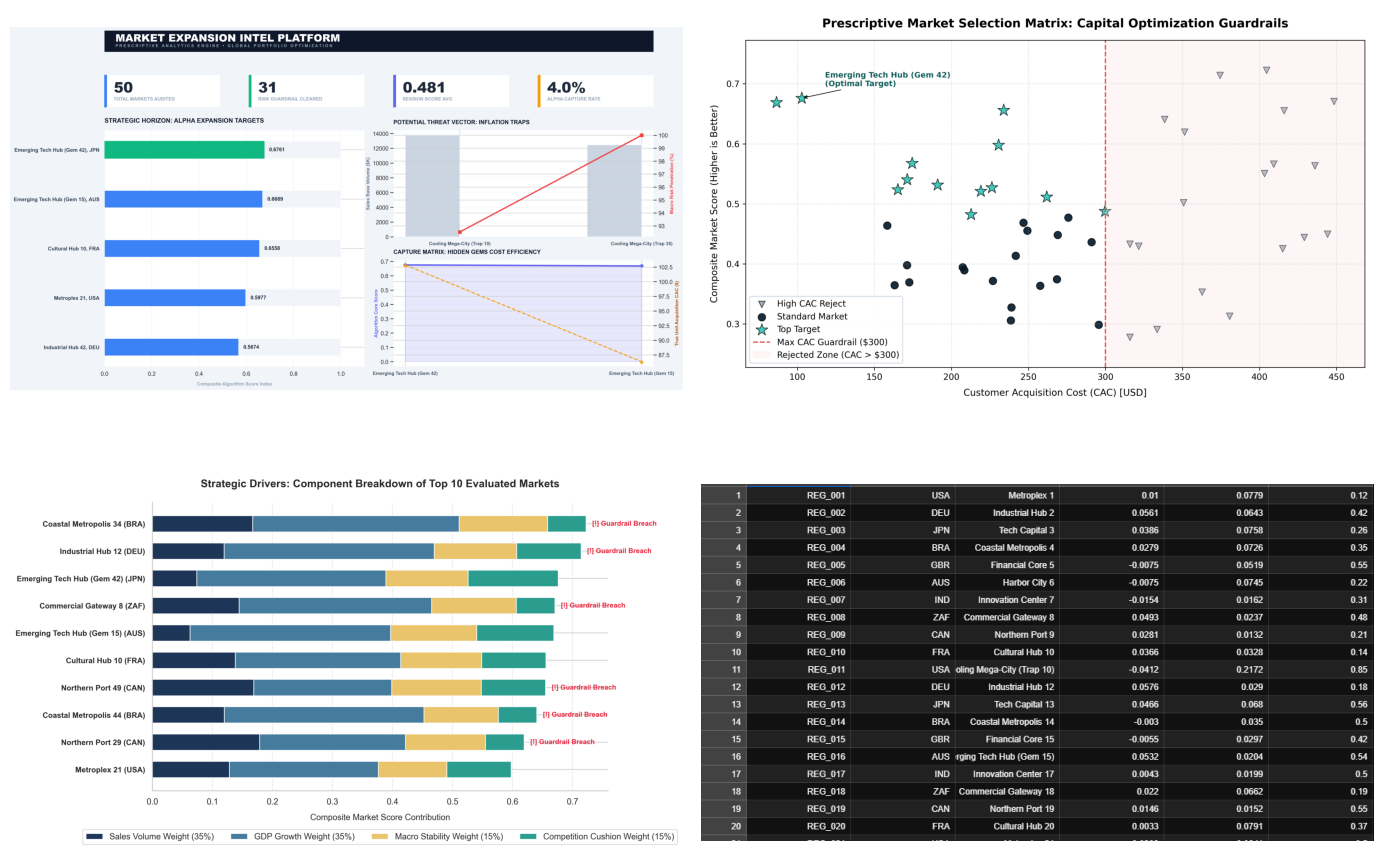

In [116]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

imgdir = Path('reports')
img = mpimg.imread(imgdir/"executive_summary_dashboard.png")
img2 = mpimg.imread(imgdir/"market_optimization_matrix.png")
img3 = mpimg.imread(imgdir/"market_scoring_breakdown.png")
img4 = mpimg.imread(imgdir/"macro_trend_data_shot.png")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

ax1.imshow(img)
ax1.axis('off')

ax2.imshow(img2)
ax2.axis('off')

ax3.imshow(img3)
ax3.axis('off')

ax4.imshow(img4)
ax4.axis('off')

plt.tight_layout()
plt.show()